In [2]:
from torch.distributions import Poisson, Normal, MultivariateNormal
from gpzoo.gp import SVGP, MGGP_SVGP, VNNGP, MGGP_WSVGP, MGGP_VNNGP
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF
from gpzoo.utilities import build_sparse_from_Kzx_knnidx, symmetrize_by_copy, add_jitter
import torch
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(0)

In [4]:
N = 50

In [5]:
X1 = torch.linspace(-2, 2, N)[:, None]
groupsX1 = torch.zeros_like(X1.squeeze()).type(torch.long)
X2 = torch.linspace(-2, 2, N)[:, None]
groupsX2 = torch.ones_like(X2.squeeze()).type(torch.long)
X = torch.cat((X1, X2))
groupsX = torch.cat((groupsX1, groupsX2)).squeeze().type(torch.long)

In [14]:
K=2*N

n_groups = 2
M = 2*N


kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=1.0, group_diff_param=100.0)
gp = MGGP_VNNGP(kernel, dim=1, M=M, n_groups=n_groups, jitter=1e-5, K=K)


gp.Z = torch.nn.Parameter(X)
gp.groupsZ = torch.nn.Parameter( groupsX, requires_grad=False)
gp.mu = torch.nn.Parameter(torch.zeros(2*N))



knn_idx = gp.calculate_knn(X)
gp.knn_idx = knn_idx[:, :-1]
gp.knn_idz= knn_idx[:, 1:]



Kxx, Kzx, Kzz = gp.forward_kernels(X, groupsX)
A = build_sparse_from_Kzx_knnidx(Kzx, knn_idx[:,:-1], 2*N)
A = symmetrize_by_copy(A)
U, S, V = torch.svd_lowrank(A, q=10, niter=K)
# U, S, V = torch.svd(A.to_dense())

W = U*(S**0.5).detach()
gp.Lu = torch.nn.Parameter(W)

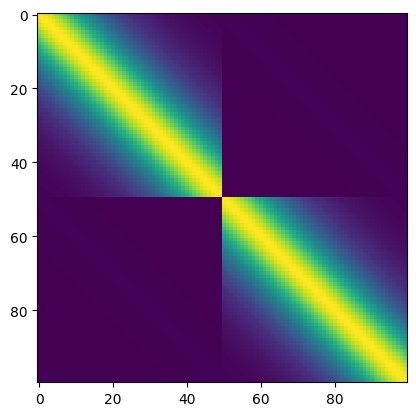

In [15]:
plt.imshow(A.to_dense().detach())

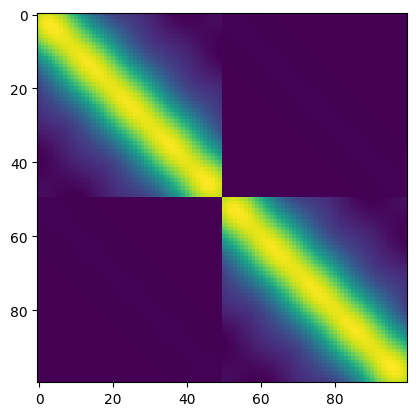

In [16]:
plt.imshow((W@W.T).detach())

In [17]:
L = torch.linalg.cholesky(add_jitter((W@W.T), 1e-5))

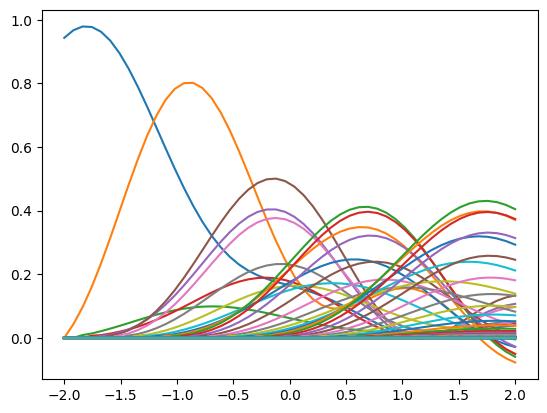

In [18]:
for i in range(K):
    plt.plot(X1, L[:N, i].detach());

In [19]:
L.shape

torch.Size([100, 100])

In [20]:
T = 120
samples = []
for t in range(0, T):
    pi_range = torch.linspace(-1, 1, K)*torch.pi
    value = pi_range+ (t*2*torch.pi/T)
    
    sample = (L[:, :K]@torch.sin(2*value)).detach()
    samples.append(sample)

# sample = (W@torch.randn(K)).detach()


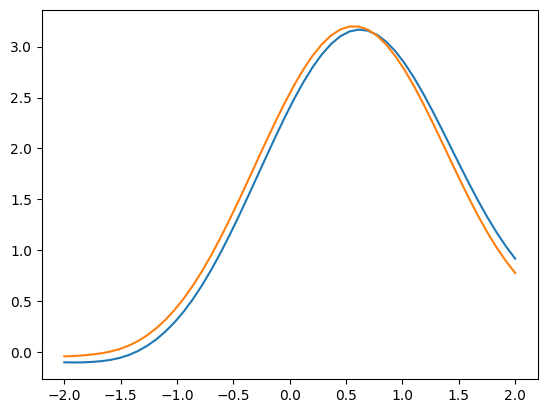

In [21]:
plt.plot(X1, sample[:N])
plt.plot(X2, sample[N:])

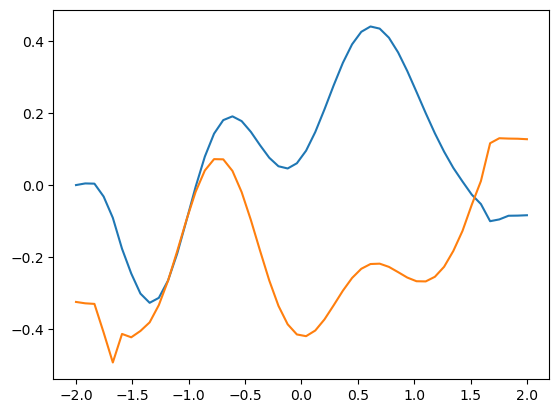

In [592]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from tqdm import tqdm

fig = plt.figure()
ax = fig.add_subplot()

def update(iteration):
    ax.cla()
        
    curr_sample = samples[iteration]
    
    ax.plot(X1, curr_sample[:N])
    ax.plot(X2, curr_sample[N:])

#     fig.suptitle(f"Iteration: {iteration}, Loss: {losses[iteration*10]:0.2f}")
#     fig.tight_layout()

anim = FuncAnimation(fig, update, frames=np.arange(0, 120, 1), interval=100)
# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save('mggp_test.mp4', fps=20, dpi=100)

In [360]:
W.shape

torch.Size([100, 10])

In [13]:
gp.Lu.shape

torch.Size([400, 400])

In [336]:
!ls

Diagonal_vs_non.ipynb  MGGPs.ipynb    presentation_september_2025.ipynb
Explore_cells.ipynb    mggp_test.mp4
